# Fig: Dev Experiment Compare Interaction Terms

Compare interaction terms with binary prev violation history vs. filtered prev violation history


In [1]:
import seaborn as sns
import matplotlib.pyplot as plt

from violmulti.experiments.experiment import load_experiment
from violmulti.experiments.experiment_compare_models import ExperimentCompareModels
from violmulti.models.multiclass_logistic_regression import MultiClassLogisticRegression
from violmulti.models.binary_logistic_regression import BinaryLogisticRegression
from violmulti.visualizations.model_visualizer import ModelVisualizer
from violmulti.features.design_matrix_generator_PWM import *

from violmulti.visualizations.model_visualizer import *

from violmulti.data import ANIMAL_IDS
from violmulti.experiments import STANDARD_SIGMAS
import config as c

sns.set_context("talk")
%load_ext autoreload
%autoreload 2

In [2]:
shared_cols = {
    "session": lambda df: (copy(df.session)),
    "bias": lambda df: (add_bias_column(df)),
    "s_a": lambda df: (standardize(df.s_a)),
    "s_b": lambda df: (standardize(df.s_b)),
    "prev_avg_stim": lambda df: prev_avg_stim(df, mask_prev_violation=True),
    "prev_correct": lambda df: (prev_correct_side(df)),
    "prev_choice": lambda df: (prev_choice(df)),
}

models_config = {
    "base" : {
        "model_class": BinaryLogisticRegression,
        "dmg_config": {
            **shared_cols,
            "labels" : binary_choice_labels(),
        },
    },
    "prev_viol_binary" : {
        "model_class": MultiClassLogisticRegression,
        "dmg_config": {
            **shared_cols,
            "prev_violation": lambda df: prev_violation(df),
            "labels": multi_choice_labels(),
        },
        "lr_only_eval": True,
    },
    "prev_viol_filtered" : {
        "model_class": MultiClassLogisticRegression,
        "dmg_config": {
            **shared_cols,
            "filt_prev_violation": lambda df: (
                filtered_prev_viol(df, get_animals_tau(df, "prev_violation", save_path=c.MODEL_FITS_PATH + "/taus_df.csv"))
            ),
            "labels": multi_choice_labels(),
        },
        "lr_only_eval": True,
    },
    "prev_viol_binary_itrx" : {
        "model_class": MultiClassLogisticRegression,
        "dmg_config": {
            **shared_cols,
            "prev_violation": lambda df: prev_violation(df),
            "sa_x_prev_viol": lambda df: stim_filt_binary_intrx(df, "s_a"),
            "sb_x_prev_viol": lambda df: stim_filt_binary_intrx(df, "s_b"),
            "labels": multi_choice_labels(),
        },
        "lr_only_eval": True,
    },
    "prev_viol_filtered_itrx" : {
        "model_class": MultiClassLogisticRegression,
        "dmg_config": {
            **shared_cols,
            "filt_prev_violation": lambda df: (
                filtered_prev_viol(df, get_animals_tau(df, "prev_violation", save_path=c.MODEL_FITS_PATH + "/taus_df.csv"))
            ),
            "sa_x_prev_viol": lambda df: (
                stim_filt_viol_intrx(df, "s_a", get_animals_tau(df, "prev_violation", save_path=c.MODEL_FITS_PATH + "/taus_df.csv"))
            ),
            "sb_x_prev_viol": lambda df: (
            stim_filt_viol_intrx(df, "s_b", get_animals_tau(df, "prev_violation", save_path=c.MODEL_FITS_PATH + "/taus_df.csv"))
             ),
            "labels": multi_choice_labels(),
        },
        "lr_only_eval":True,
    },
}
params = {
    "animals": ANIMAL_IDS,
    "data_type": "new_trained_cleaned",
    "sigmas": STANDARD_SIGMAS,
    "random_state": 47,
    "eval_train": True,
    "null_mode": "binary",
    "model_config": models_config,
}

save_name = "2025_07_22_fig5_compare_to_binary_rs47.pkl"

ORDER = [
    "base",
    "prev_viol_binary",
    "prev_viol_binary_itrx",
    "prev_viol_filtered",
    "prev_viol_filtered_itrx",
]

## Run


In [3]:
experiment = ExperimentCompareModels(params)
experiment.run()
experiment.save(save_name, file_path=c.MODEL_FITS_PATH)

Loading dataset type : new_trained_cleaned
DataLoader: Loading data type:  new_trained_cleaned  for animal ids:  ['W051', 'W060', 'W065', 'W066', 'W068', 'W072', 'W073', 'W074', 'W075', 'W078', 'W080', 'W081', 'W083', 'W088', 'W089', 'W094']

 >>>> evaluating animal W051 <<<<

 ***** evaluating model base w/ sigma 0.07 *****
         Current function value: 31996.010443
         Iterations: 13
         Function evaluations: 69
         Gradient evaluations: 57

 ***** evaluating model base w/ sigma 0.13 *****
         Current function value: 32387.580144
         Iterations: 13
         Function evaluations: 59
         Gradient evaluations: 47

 ***** evaluating model base w/ sigma 0.25 *****
         Current function value: 32527.683346
         Iterations: 13
         Function evaluations: 57
         Gradient evaluations: 45

 ***** evaluating model base w/ sigma 0.5 *****
         Current function value: 32568.830990
         Iterations: 13
         Function evaluations: 61
      

## Visualize


In [4]:
experiment = load_experiment(save_name, save_path=c.MODEL_FITS_PATH)
mvc = ModelVisualizerCompare(experiment)

/var/folders/__/8jn6qz211155h1xb451s5zcr0000gn/T/ipykernel_30649/2431235986.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for model_name, model_df in df.groupby("model_name"):


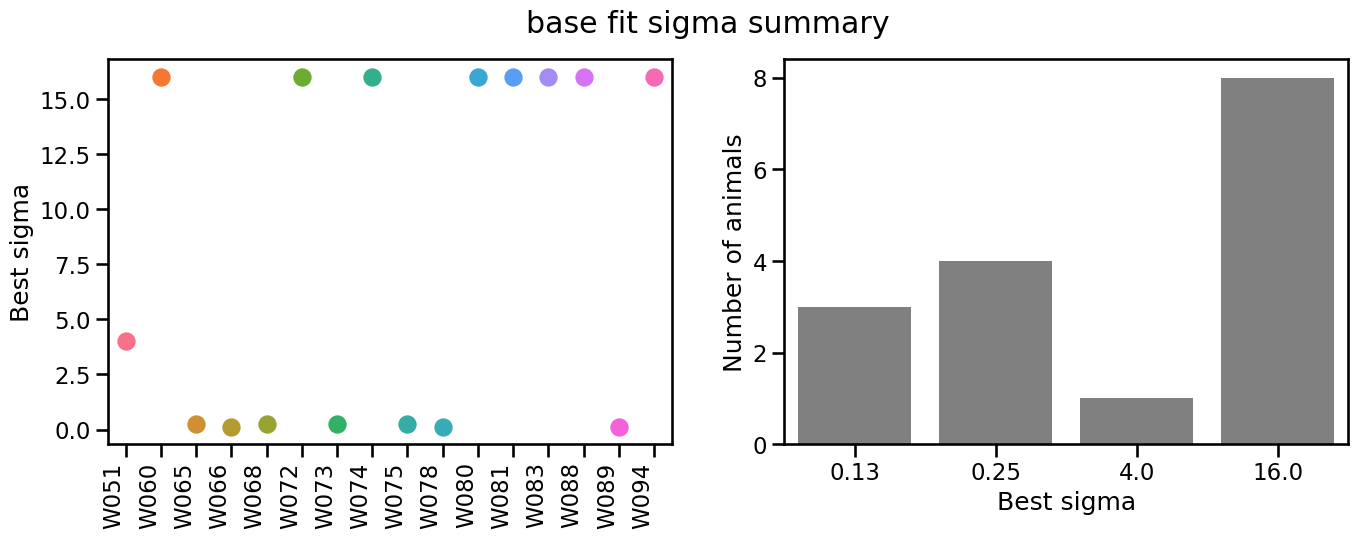

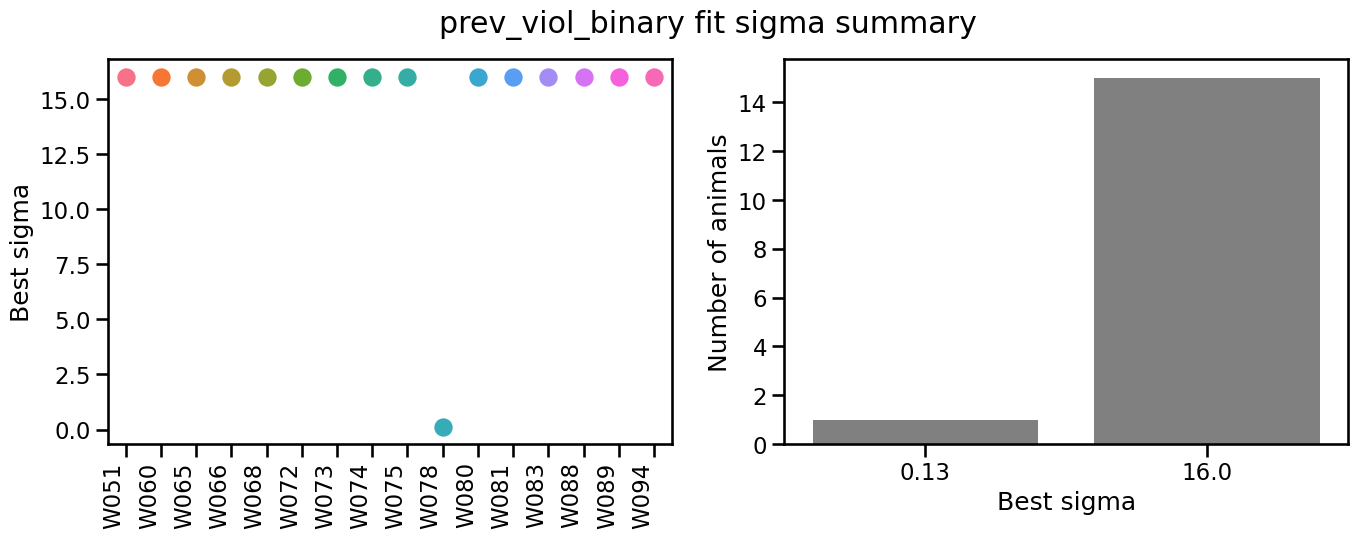

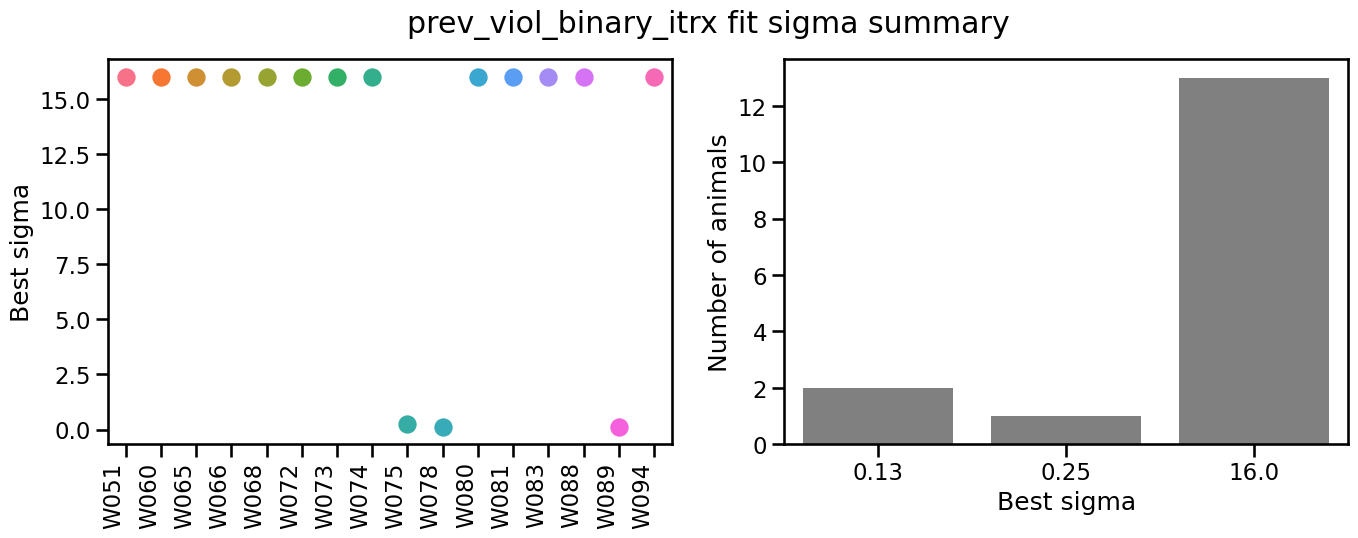

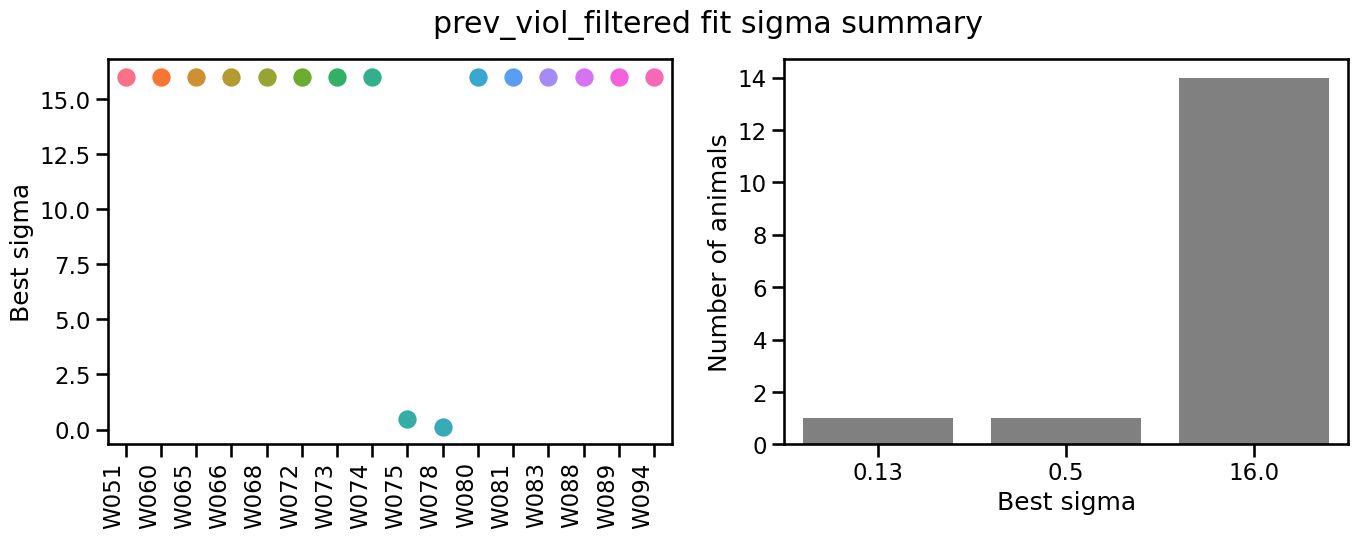

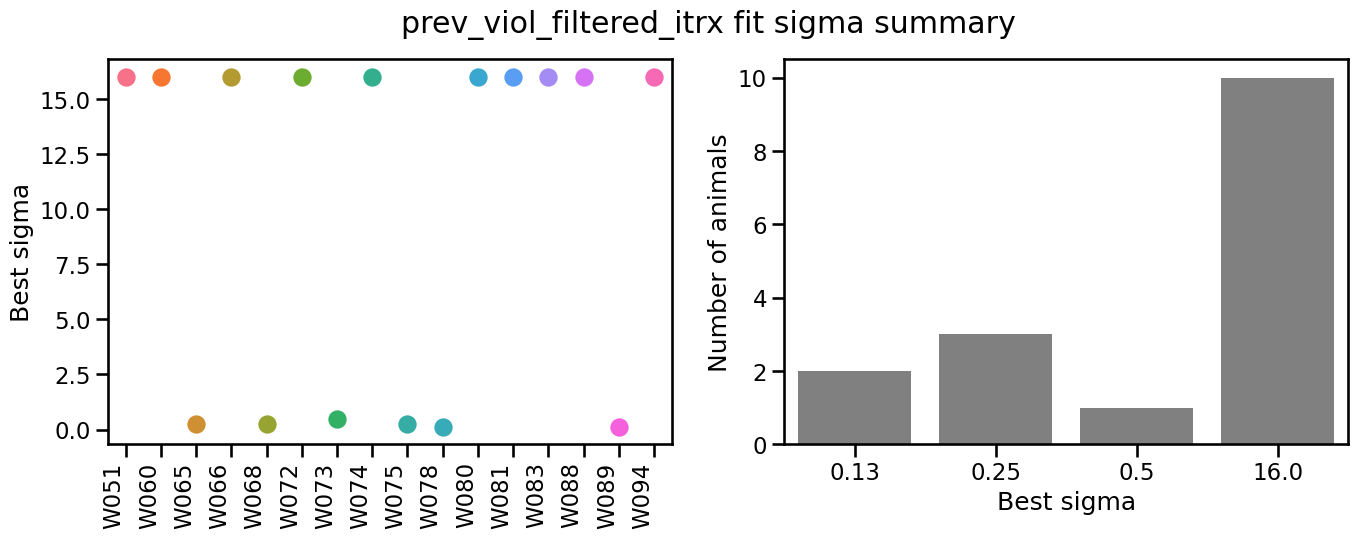

In [5]:
df = mvc.find_best_fit(group="model_name")
df["model_name"] = pd.Categorical(df["model_name"], categories=ORDER, ordered=True)
for model_name, model_df in df.groupby("model_name"):
    mvc.plot_sigma_summary(model_df, title=f"{model_name} fit sigma summary")

/var/folders/__/8jn6qz211155h1xb451s5zcr0000gn/T/ipykernel_30649/3658154948.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for ii, (model_name, model_df) in enumerate(best_fit_by_model.groupby("model_name")):
/Users/jessbreda/Desktop/github/violations-multinomial/src/violmulti/visualizations/model_visualizer.py:347: UserWarning: The palette list has more values (3) than needed (1), which may not be intended.
  sns.barplot(


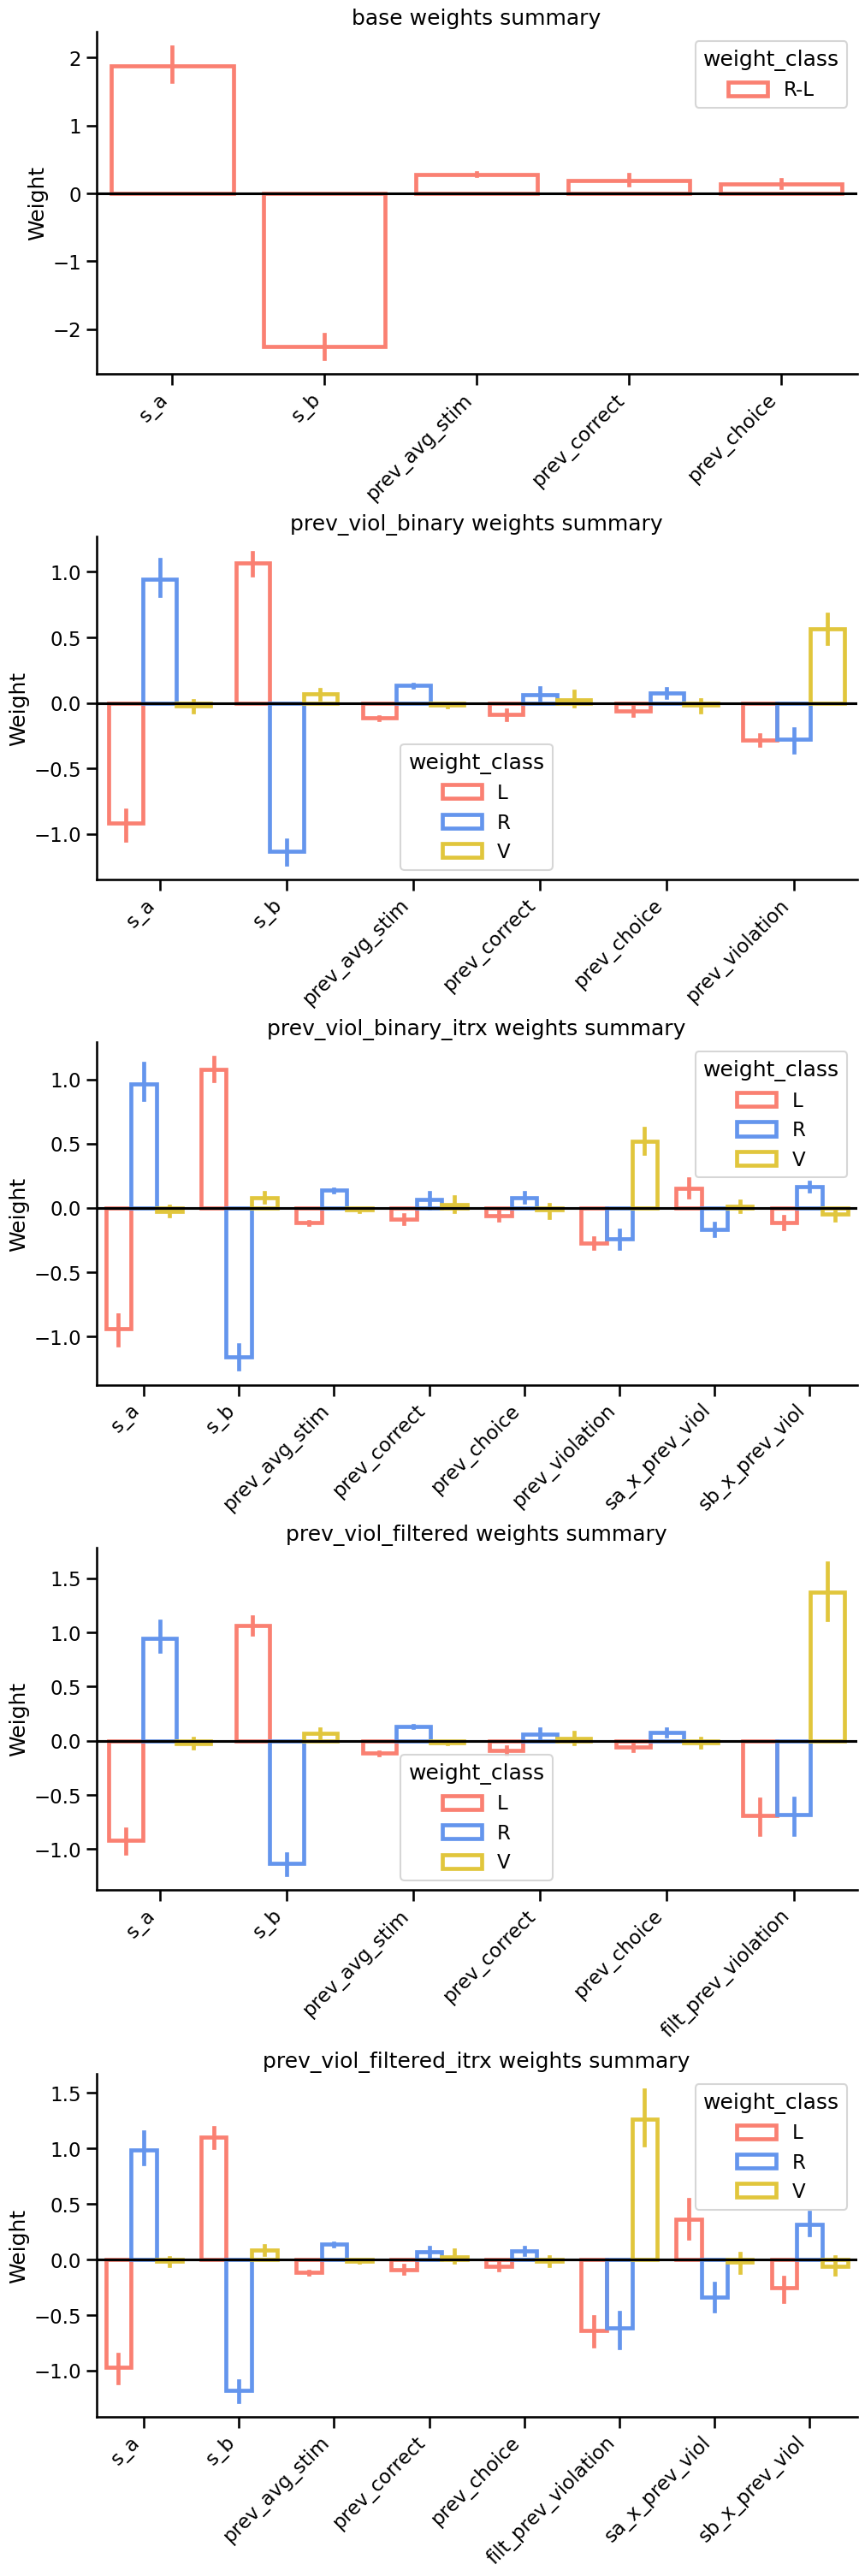

In [6]:
fig, ax = plt.subplots(
    len(ORDER), 1, figsize=(10, len(ORDER) * 6), constrained_layout=True, sharey=False
)

best_fit_by_model = mvc.find_best_fit(group=["animal_id", "model_name"])
best_fit_by_model["model_name"] = pd.Categorical(
    best_fit_by_model["model_name"], categories=ORDER, ordered=True
)

for ii, (model_name, model_df) in enumerate(best_fit_by_model.groupby("model_name")):
    unpacked = mvc.unpack_features_and_weights(model_df)

    mvc.plot_weights_summary(
        df=unpacked,
        ax=ax[ii],
        palette=c.MULTI_CHOICE_PAL,
        title=f"{model_name} weights summary",
    )

/var/folders/__/8jn6qz211155h1xb451s5zcr0000gn/T/ipykernel_30649/2177012689.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()


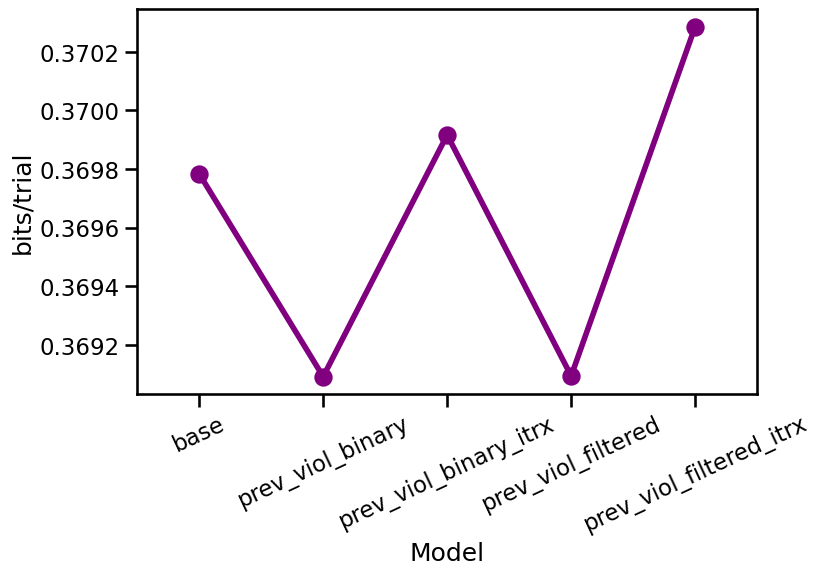

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
mvc.plot_model_comparison(
    ax=ax,
    order=ORDER,
    color="purple",
    errorbar=None,
)
ax.legend().remove()

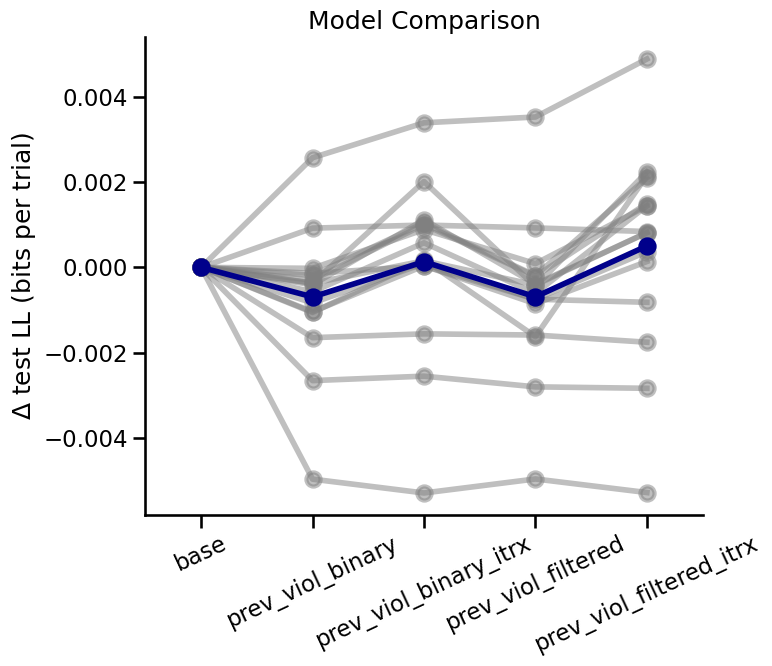

In [8]:
fig, ax = plt.subplots(figsize=(8, 7))
sns.despine()
mvc.plot_model_comparison(
    hue="animal_id",
    ax=ax,
    order=ORDER,
    palette=["gray"] * 16,
    alpha = 0.5,
    y="bits_per_trial_relative_to_base"
)
mvc.plot_model_comparison(
    ax=ax,
    order=ORDER,
    color=c.MODEL_COMPARE_COLOR,
    errorbar=None,
    y="bits_per_trial_relative_to_base",
    ylabel="$\Delta$ test LL (bits per trial)",
)
# ax.set_xticks(range(len(LABELS)))
# ax.set_xticklabels(LABELS, rotation=0)
ax.legend().remove()
ax.set(xlabel="", title="Model Comparison")

# save fig
plt.tight_layout()

In [9]:
bpt = mvc.compute_bits_per_trial_df()

bpt.groupby("model_name").bits_per_trial_relative_to_base.agg(["mean", "std"])

,mean,std
model_name,,
base,0.000000,0.000000
null,-1.369610,0.084161
prev_viol_binary,-0.000692,0.001592
prev_viol_binary_itrx,0.000133,0.001961
prev_viol_filtered,-0.000690,0.001753
prev_viol_filtered_itrx,0.000502,0.002340
